In [8]:
import struct
import numpy as np

def load_idx_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def load_idx_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

def rotate(images):
    images = np.array([np.rot90(np.fliplr(img)) for img in images])
    return images

train_images = load_idx_images('../data/original/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('../data/original/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('../data/original/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('../data/original/emnist-byclass-test-labels-idx1-ubyte')

train_images = rotate(train_images)
test_images = rotate(test_images)
mapping = {}
# Digits
for i in range(10):
    mapping[i] = str(i)
# Lowercase letters
for i in range(26):
    mapping[10 + i] = chr(65 + i)
# Uppercase letters
for i in range(26):
    mapping[36 + i] = chr(97 + i)

In [ ]:
import numpy as np
import struct
import os
from scipy.ndimage import rotate, shift, zoom, map_coordinates, gaussian_filter


def balance_dataset_augmentation(train_images, train_labels, mapping):
    num_classes = len(mapping)
    
    class_counts = [np.sum(train_labels == c) for c in range(num_classes)]
    target_count = int(np.mean(class_counts))
    print(f"Target count per class: {target_count}")
    
    balanced_images = []
    balanced_labels = []
    
    for c in range(num_classes):
        idx = np.where(train_labels == c)[0]
        class_images = train_images[idx]
        current_count = len(class_images)
        
        print(f"Class {c} ({list(mapping.values())[c]}): {current_count} -> {target_count}")
        
        if current_count >= target_count:
            selected_idx = np.random.choice(current_count, target_count, replace=False)
            balanced_images.append(class_images[selected_idx])
            balanced_labels.extend([c] * target_count)
        else:
            balanced_images.append(class_images)
            balanced_labels.extend([c] * current_count)
            
            need_more = target_count - current_count
            augmented = []
            angles = np.linspace(-12, 12, 25)
            
            while len(augmented) < need_more:
                img_idx = np.random.randint(0, current_count)
                img = class_images[img_idx]
                angle = np.random.choice(angles)
                
                rotated = rotate(img, angle, reshape=False, order=1, mode='constant', cval=0)
                rotated = np.clip(rotated, 0, 255).astype(np.uint8)
                augmented.append(rotated)
            
            augmented = np.array(augmented[:need_more])
            balanced_images.append(augmented)
            balanced_labels.extend([c] * need_more)
    
    balanced_images = np.concatenate(balanced_images, axis=0)
    balanced_labels = np.array(balanced_labels)
    
    shuffle_idx = np.random.permutation(len(balanced_labels))
    balanced_images = balanced_images[shuffle_idx]
    balanced_labels = balanced_labels[shuffle_idx]
    
    print(f"\nOriginal dataset size: {len(train_images)}")
    print(f"Balanced dataset size: {len(balanced_images)}")
    
    return balanced_images, balanced_labels


def add_realistic_noise(train_images, train_labels, noise_level='medium'):
    noisy_images = train_images.copy().astype(np.float32)
    
    if noise_level == 'light':
        gaussian_std = 5
        salt_pepper_prob = 0.005
        texture_intensity = 0.1
    elif noise_level == 'medium':
        gaussian_std = 10
        salt_pepper_prob = 0.01
        texture_intensity = 0.2
    else:  # heavy
        gaussian_std = 15
        salt_pepper_prob = 0.02
        texture_intensity = 0.3
    
    for i in range(len(noisy_images)):
        img = noisy_images[i]
        
        # Gaussian noise
        gaussian = np.random.normal(0, gaussian_std, img.shape)
        img = img + gaussian
        
        # Salt and pepper noise
        salt_pepper = np.random.random(img.shape)
        img[salt_pepper < salt_pepper_prob] = 255
        img[salt_pepper > (1 - salt_pepper_prob)] = 0
        
        # Texture noise
        texture = np.random.uniform(-texture_intensity * 255, 
                                   texture_intensity * 255, 
                                   img.shape)
        background_mask = img < 50
        img[background_mask] += texture[background_mask]
        
        # Blur
        if np.random.random() < 0.3:
            img = gaussian_filter(img, sigma=0.5)
        
        # Brightness
        brightness_factor = np.random.uniform(0.8, 1.2)
        img = img * brightness_factor
        
        noisy_images[i] = np.clip(img, 0, 255)
    
    noisy_images = noisy_images.astype(np.uint8)
    return noisy_images, train_labels


def elastic_transform(image, alpha, sigma, random_state=None):
    if random_state is None:
        random_state = np.random.RandomState(None)

    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape) * 2 - 1),
                          sigma, mode="constant") * alpha
    dy = gaussian_filter((random_state.rand(*shape) * 2 - 1),
                          sigma, mode="constant") * alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))

    distorted = map_coordinates(image, indices, order=1, mode='constant')
    return distorted.reshape(shape)


def random_shift_zoom(img, shift_range=0.12, zoom_range=0.12):
    h, w = img.shape

    # Shift
    tx = np.random.uniform(-shift_range, shift_range) * w
    ty = np.random.uniform(-shift_range, shift_range) * h
    shifted = shift(img, shift=(ty, tx), mode='constant', cval=0)

    # Zoom
    zoom_factor = np.random.uniform(1 - zoom_range, 1 + zoom_range)
    zoomed = zoom(shifted, zoom_factor, order=1)

    # Crop or pad back to 28x28
    zh, zw = zoomed.shape
    if zh > 28:
        start_h = (zh - 28) // 2
        start_w = (zw - 28) // 2
        zoomed = zoomed[start_h:start_h+28, start_w:start_w+28]
    else:
        pad_h = (28 - zh) // 2
        pad_w = (28 - zw) // 2
        zoomed = np.pad(
            zoomed,
            ((pad_h, 28 - zh - pad_h), (pad_w, 28 - zw - pad_w)),
            mode='constant'
        )

    return zoomed


def advanced_handwriting_augmentation(images, labels, intensity='medium'):
    augmented_images = []
    augmented_labels = []

    if intensity == 'light':
        alpha, sigma = 20, 3
        prob = 0.5
    elif intensity == 'medium':
        alpha, sigma = 30, 4
        prob = 0.7
    else:  # heavy
        alpha, sigma = 40, 5
        prob = 0.9

    for i in range(len(images)):
        img = images[i]

        if np.random.rand() < prob:
            img = elastic_transform(img, alpha=alpha, sigma=sigma)

        if np.random.rand() < prob:
            img = random_shift_zoom(img)

        img = np.clip(img, 0, 255).astype(np.uint8)

        augmented_images.append(img)
        augmented_labels.append(labels[i])

    return np.array(augmented_images), np.array(augmented_labels)

def write_idx_images(filename, images):
    num_images = images.shape[0]
    num_rows = images.shape[1]
    num_cols = images.shape[2]
    
    with open(filename, 'wb') as f:
        f.write(struct.pack('>I', 2051))
        f.write(struct.pack('>I', num_images))
        f.write(struct.pack('>I', num_rows))
        f.write(struct.pack('>I', num_cols))
        f.write(images.tobytes())
    
    print(f"Written {num_images} images to {filename}")


def write_idx_labels(filename, labels):
    num_labels = len(labels)
    
    with open(filename, 'wb') as f:
        f.write(struct.pack('>I', 2049))
        f.write(struct.pack('>I', num_labels))
        f.write(labels.astype(np.uint8).tobytes())
    
    print(f"Written {num_labels} labels to {filename}")

def export_balanced_dataset(train_images, train_labels, test_images, test_labels,
                           mapping, output_dir='../data/balanced'):
    os.makedirs(output_dir, exist_ok=True)
    
    balanced_train_images, balanced_train_labels = balance_dataset_augmentation(
        train_images, train_labels, mapping
    )
    
    write_idx_images(
        f'{output_dir}/emnist-byclass-train-images-idx3-ubyte',
        balanced_train_images
    )
    write_idx_labels(
        f'{output_dir}/emnist-byclass-train-labels-idx1-ubyte',
        balanced_train_labels
    )
    write_idx_images(
        f'{output_dir}/emnist-byclass-test-images-idx3-ubyte',
        test_images
    )
    write_idx_labels(
        f'{output_dir}/emnist-byclass-test-labels-idx1-ubyte',
        test_labels
    )
    
    print(f"Train: {len(balanced_train_images)} images")
    print(f"Test: {len(test_images)} images")


def export_noisy_dataset(train_images, train_labels, test_images, test_labels,
                        output_dir='../data/noisy', noise_level='medium'):
    os.makedirs(output_dir, exist_ok=True)

    noisy_train_images, noisy_train_labels = add_realistic_noise(
        train_images, train_labels, noise_level=noise_level
    )
    
    noisy_test_images, noisy_test_labels = add_realistic_noise(
        test_images, test_labels, noise_level='light'
    )
    
    write_idx_images(
        f'{output_dir}/emnist-byclass-train-images-idx3-ubyte',
        noisy_train_images
    )
    write_idx_labels(
        f'{output_dir}/emnist-byclass-train-labels-idx1-ubyte',
        noisy_train_labels
    )
    write_idx_images(
        f'{output_dir}/emnist-byclass-test-images-idx3-ubyte',
        noisy_test_images
    )
    write_idx_labels(
        f'{output_dir}/emnist-byclass-test-labels-idx1-ubyte',
        noisy_test_labels
    )
    
    print(f"Train: {len(noisy_train_images)} images")
    print(f"Test: {len(noisy_test_images)} images")


def export_combined_dataset(train_images, train_labels, test_images, test_labels,
                           mapping, output_dir='../data/combined', noise_level='medium'):
    os.makedirs(output_dir, exist_ok=True)
    
    balanced_train_images, balanced_train_labels = balance_dataset_augmentation(
        train_images, train_labels, mapping
    )
    
    noisy_balanced_train_images, noisy_balanced_train_labels = add_realistic_noise(
        balanced_train_images, balanced_train_labels, noise_level=noise_level
    )
    
    noisy_test_images, noisy_test_labels = add_realistic_noise(
        test_images, test_labels, noise_level='light'
    )
    
    write_idx_images(
        f'{output_dir}/emnist-byclass-train-images-idx3-ubyte',
        noisy_balanced_train_images
    )
    write_idx_labels(
        f'{output_dir}/emnist-byclass-train-labels-idx1-ubyte',
        noisy_balanced_train_labels
    )
    write_idx_images(
        f'{output_dir}/emnist-byclass-test-images-idx3-ubyte',
        noisy_test_images
    )
    write_idx_labels(
        f'{output_dir}/emnist-byclass-test-labels-idx1-ubyte',
        noisy_test_labels
    )
    
    print(f"Train: {len(noisy_balanced_train_images)} images")
    print(f"Test: {len(noisy_test_images)} images")


def export_elastic_dataset(train_images, train_labels, test_images, test_labels,
                           output_dir='../data/elastic'):
    os.makedirs(output_dir, exist_ok=True)

    aug_train_images, aug_train_labels = advanced_handwriting_augmentation(
        train_images, train_labels, intensity='medium'
    )

    write_idx_images(
        f'{output_dir}/emnist-byclass-train-images-idx3-ubyte',
        aug_train_images
    )
    write_idx_labels(
        f'{output_dir}/emnist-byclass-train-labels-idx1-ubyte',
        aug_train_labels
    )
    write_idx_images(
        f'{output_dir}/emnist-byclass-test-images-idx3-ubyte',
        test_images
    )
    write_idx_labels(
        f'{output_dir}/emnist-byclass-test-labels-idx1-ubyte',
        test_labels
    )

    print(f"Train: {len(aug_train_images)} images")
    print(f"Test: {len(test_images)} images")
    
export_balanced_dataset(train_images, train_labels, test_images, test_labels,
                        mapping, output_dir='../data/balanced')

export_noisy_dataset(train_images, train_labels, test_images, test_labels,
                    output_dir='../data/noisy', noise_level='medium')

export_combined_dataset(train_images, train_labels, test_images, test_labels,
                        mapping, output_dir='../data/combined', noise_level='medium')

export_elastic_dataset(train_images, train_labels, test_images, test_labels,
                        output_dir='../data/elastic')



Target count per class: 11256
Class 0 (0): 34585 -> 11256
Class 1 (1): 38374 -> 11256
Class 2 (2): 34203 -> 11256
Class 3 (3): 35143 -> 11256
Class 4 (4): 33535 -> 11256
Class 5 (5): 31416 -> 11256
Class 6 (6): 34232 -> 11256
Class 7 (7): 35754 -> 11256
Class 8 (8): 33946 -> 11256
Class 9 (9): 33847 -> 11256
Class 10 (A): 6407 -> 11256
Class 11 (B): 3878 -> 11256
Class 12 (C): 10094 -> 11256
Class 13 (D): 4562 -> 11256
Class 14 (E): 4934 -> 11256
Class 15 (F): 9182 -> 11256
Class 16 (G): 2517 -> 11256
Class 17 (H): 3152 -> 11256
Class 18 (I): 11946 -> 11256
Class 19 (J): 3762 -> 11256
Class 20 (K): 2468 -> 11256
Class 21 (L): 5076 -> 11256
Class 22 (M): 9002 -> 11256
Class 23 (N): 8237 -> 11256
Class 24 (O): 24983 -> 11256
Class 25 (P): 8347 -> 11256
Class 26 (Q): 2605 -> 11256
Class 27 (R): 5073 -> 11256
Class 28 (S): 20764 -> 11256
Class 29 (T): 9820 -> 11256
Class 30 (U): 12602 -> 11256
Class 31 (V): 4637 -> 11256
Class 32 (W): 4695 -> 11256
Class 33 (X): 2771 -> 11256
Class 34 (Y):

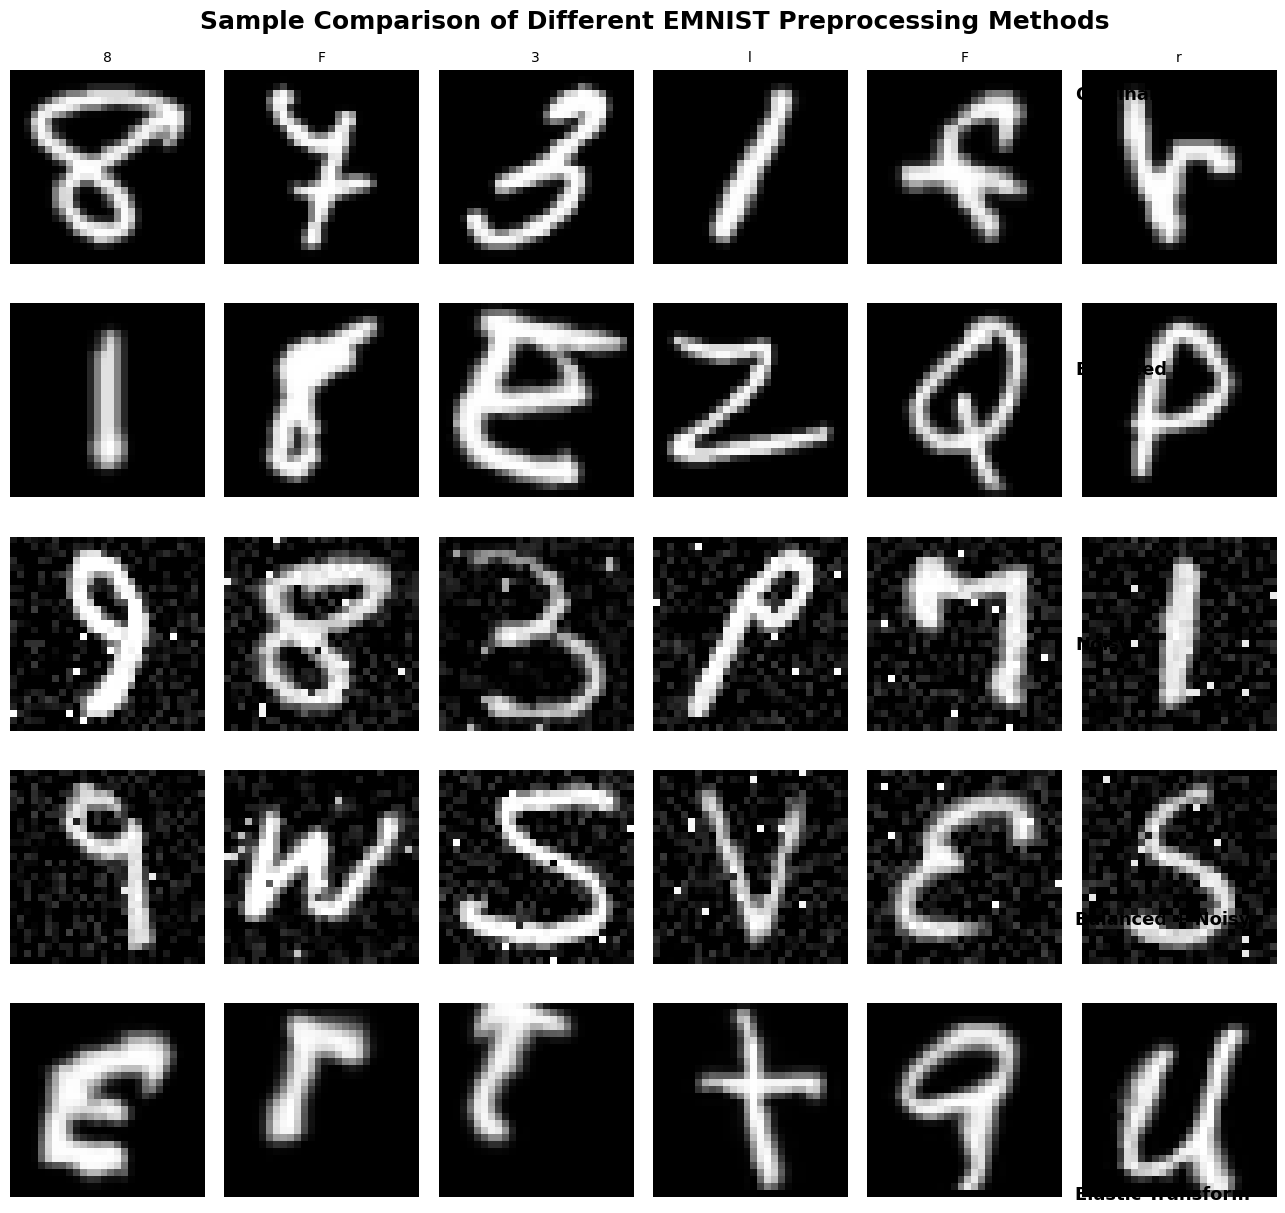

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def show_samples_per_dataset(datasets, labels, titles, mapping, samples_per_set=6):
    num_sets = len(datasets)
    plt.figure(figsize=(samples_per_set * 2.2, num_sets * 2.5))

    for r, (images, lbls, title) in enumerate(zip(datasets, labels, titles)):
        idxs = np.random.choice(len(images), samples_per_set, replace=False)

        for c, idx in enumerate(idxs):
            plt.subplot(num_sets, samples_per_set, r * samples_per_set + c + 1)
            plt.imshow(images[idx], cmap='gray')
            plt.axis('off')

            if r == 0:
                plt.title(
                    f"{mapping[lbls[idx]]}",
                    fontsize=10
                )

        plt.text(
            -1.5, 
            r * samples_per_set + samples_per_set // 2,
            title,
            fontsize=13,
            fontweight='bold',
            va='center'
        )

    plt.suptitle("Sample Comparison of Different EMNIST Preprocessing Methods",
                 fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

orig_images, orig_labels = train_images, train_labels

bal_images = load_idx_images('../data/balanced/emnist-byclass-train-images-idx3-ubyte')
bal_labels = load_idx_labels('../data/balanced/emnist-byclass-train-labels-idx1-ubyte')

noisy_images = load_idx_images('../data/noisy/emnist-byclass-train-images-idx3-ubyte')
noisy_labels = load_idx_labels('../data/noisy/emnist-byclass-train-labels-idx1-ubyte')

combined_images = load_idx_images('../data/combined/emnist-byclass-train-images-idx3-ubyte')
combined_labels = load_idx_labels('../data/combined/emnist-byclass-train-labels-idx1-ubyte')

elastic_images = load_idx_images('../data/elastic/emnist-byclass-train-images-idx3-ubyte')
elastic_labels = load_idx_labels('../data/elastic/emnist-byclass-train-labels-idx1-ubyte')


show_samples_per_dataset(
    datasets=[
        orig_images,
        bal_images,
        noisy_images,
        combined_images,
        elastic_images
    ],
    labels=[
        orig_labels,
        bal_labels,
        noisy_labels,
        combined_labels,
        elastic_labels
    ],
    titles=[
        "Original",
        "Balanced",
        "Noisy",
        "Balanced + Noisy",
        "Elastic Transform"
    ],
    mapping=mapping,
    samples_per_set=6
)


In [11]:
import os
import zipfile

base_dir = "../data"
datasets = ["original", "balanced", "noisy", "combined", "elastic"]

for name in datasets:
    folder = os.path.join(base_dir, name)
    zip_path = os.path.join(base_dir, f"{name}.zip")

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
        for root, _, files in os.walk(folder):
            for f in files:
                full_path = os.path.join(root, f)
                z.write(full_path, arcname=os.path.relpath(full_path, base_dir))

    print(f"Zipped: {zip_path}")


Zipped: ../data\original.zip
Zipped: ../data\balanced.zip
Zipped: ../data\noisy.zip
Zipped: ../data\combined.zip
Zipped: ../data\elastic.zip
